In [17]:
import pandas as pd
import numpy as np
df=pd.read_pickle(f"../df24.pkl")
y=df['dm']
X=df.drop(columns=['dm'])

In [18]:
import torch.cuda
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


True
NVIDIA GeForce RTX 4070 SUPER


Random Forest Classifier

In [19]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import r2_score, root_mean_squared_error


# =========================
# 1. Train / Test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(y.value_counts())


# =========================
# 2. Preprocessing
# =========================
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), [
            'age', 'chol', 'hdl', 'tg', 'ldl', 'sbp', 'wt', 'ht', 'wc', 'bmi',
            'wk_smk', 'wk_alc', 'wk_mvpa_work', 'wk_mvpa_play', 'wk_walk',
            'wk_sleep', 'glu', 'hba1c', 'stress', 'wk_break', 'wk_lunch',
            'wk_dinner', 'wk_veg1', 'wk_veg2', 'wk_fruit', 'edu', 'income'
        ]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ['sex', 'job'])
    ]
)


# =========================
# 3. Random Forest 모델 정의
# =========================
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


# =========================
# 4. Pipeline 구성
# =========================
pipe = Pipeline([
    ("preprocess", preprocess),
    ("rf", model)
])


# =========================
# 5. 모델 학습
# =========================
pipe.fit(X_train, y_train)


# =========================
# 6. 예측
# =========================
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)


# =========================
# 7. 기본 분류 성능
# =========================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1 score: {f1:.4f}")
# print(f"r2:{r2}, rmse:{rmse}")


dm
0    2227
1    1402
2     696
Name: count, dtype: int64
Accuracy: 0.9491, Precision: 0.9499, Recall: 0.9491, F1 score: 0.9478


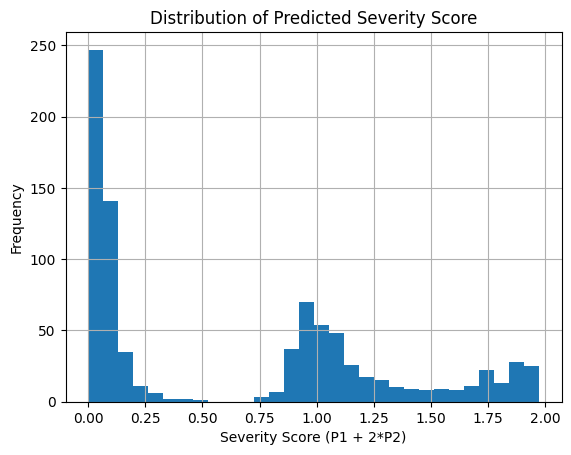

In [20]:
import matplotlib.pyplot as plt

y_score = y_proba[:, 1] + 2 * y_proba[:, 2]
y_score_series = pd.Series(y_score)

y_score_series.hist(bins=30)
plt.xlabel("Severity Score (P1 + 2*P2)")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Severity Score")
plt.show()

SVC

In [21]:
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import r2_score, root_mean_squared_error


# =========================
# 1. Train / Test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(y.value_counts())


# =========================
# 2. Preprocessing
# =========================
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), [
            'age', 'chol', 'hdl', 'tg', 'ldl', 'sbp', 'wt', 'ht', 'wc', 'bmi',
            'wk_smk', 'wk_alc', 'wk_mvpa_work', 'wk_mvpa_play', 'wk_walk',
            'wk_sleep', 'glu', 'hba1c', 'stress', 'wk_break', 'wk_lunch',
            'wk_dinner', 'wk_veg1', 'wk_veg2', 'wk_fruit', 'edu', 'income'
        ]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ['sex', 'job'])
    ]
)


# =========================
# 3. SVC 모델 정의
# =========================
model = SVC(
    kernel="rbf",          # 기본 RBF 커널
    C=1.0,
    gamma="scale",
    probability=True,      # predict_proba 사용 위해 필수
    random_state=42
)


# =========================
# 4. Pipeline 구성
# =========================
pipe = Pipeline([
    ("preprocess", preprocess),
    ("svc", model)
])


# =========================
# 5. 모델 학습
# =========================
pipe.fit(X_train, y_train)


# =========================
# 6. 예측
# =========================
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)


# =========================
# 7. 기본 분류 성능
# =========================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1 score: {f1:.4f}")
# print(f"r2:{r2}, rmse:{rmse}")


dm
0    2227
1    1402
2     696
Name: count, dtype: int64
Accuracy: 0.8543, Precision: 0.8555, Recall: 0.8543, F1 score: 0.8529


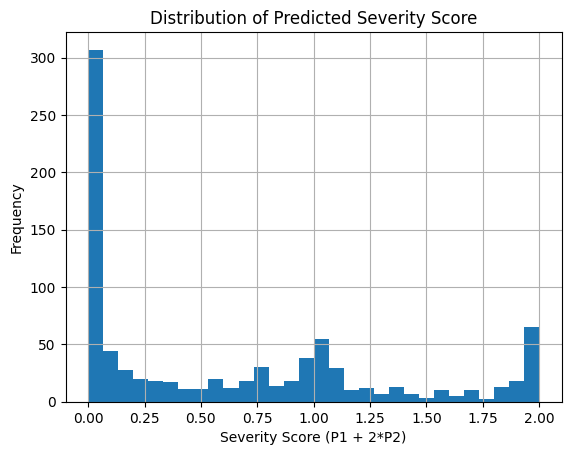

In [22]:
import matplotlib.pyplot as plt

y_score = y_proba[:, 1] + 2 * y_proba[:, 2]
y_score_series = pd.Series(y_score)

y_score_series.hist(bins=30)
plt.xlabel("Severity Score (P1 + 2*P2)")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Severity Score")
plt.show()